# 02 - Five-Fold Model Comparison

This notebook explains how five trainable text configurations and one dummy baseline were compared. Model selection uses only the 1,500 training issues.


## Step 1 - Locate the project and load the saved cross-validation run


In [1]:
# Step 1: Locate the project root and import our package from src/.
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src" / "issue_classifier").is_dir():
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("Could not find AI4SE_FINAL_PROJECT/src/issue_classifier")
    PROJECT_ROOT = PROJECT_ROOT.parent

source_dir = str(PROJECT_ROOT / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\AI4SE_FINAL_PROJECT


In [2]:
# Step 1: Read the executed cross-validation result instead of recomputing it in the notebook.
import json
import pandas as pd
from IPython.display import Image, display

cv_path = PROJECT_ROOT / "results" / "cross_validation.json"
cv = json.loads(cv_path.read_text(encoding="utf-8"))
print(f"Seed: {cv['seed']}")
print(f"Folds per repository: {cv['fold_count']}")
print(f"Selected candidate: {cv['selected_candidate']}")


Seed: 42
Folds per repository: 5
Selected candidate: word_char_tfidf_svc_c1


## Step 2 - Inspect all six candidates


In [3]:
# Step 2: Show the score used for selection and the variation across 25 fold scores.
candidate_table = pd.DataFrame(
    [
        {
            "candidate": item["candidate"],
            "mean_macro_f1": item["global_mean"],
            "population_std": item["global_std"],
            "fold_scores": item["fold_count"],
        }
        for item in cv["summaries"]
    ]
).sort_values("mean_macro_f1", ascending=False)

candidate_table.style.format(
    {"mean_macro_f1": "{:.6f}", "population_std": "{:.6f}"}
)


,candidate,mean_macro_f1,population_std,fold_scores
4,word_char_tfidf_svc_c1,0.748487,0.055525,25
2,word_tfidf_logreg_c4,0.747260,0.071377,25
5,word_char_tfidf_svc_c2,0.746119,0.056610,25
3,word_char_tfidf_svc_c0_5,0.744043,0.064428,25
1,word_tfidf_logreg_c1,0.729641,0.072886,25
0,dummy_most_frequent,0.166667,0.000000,25


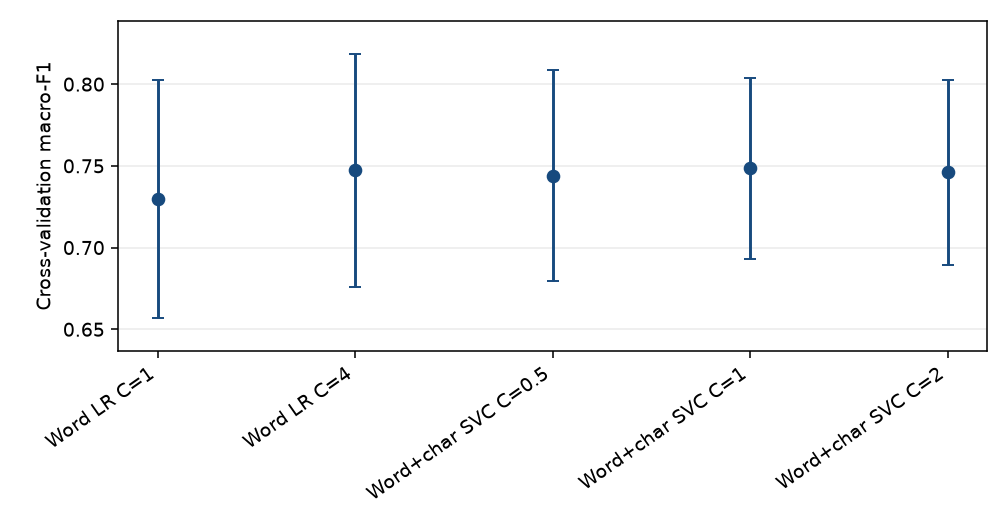

In [4]:
# Step 2 continued: Display the zoomed comparison generated from the saved fold scores.
comparison_figure = (
    PROJECT_ROOT / "report" / "generated" / "figures" /
    "cross-validation-candidates.png"
)
display(Image(filename=str(comparison_figure), width=850))


## Step 3 - Inspect the selected configuration


In [5]:
# Step 3: Print the exact TF-IDF and LinearSVC parameters selected by five-fold CV.
selected_name = cv["selected_candidate"]
selected = cv["candidate_parameters"][selected_name]
pd.Series(selected["parameters"], name="selected value").to_frame()


,selected value
C,1
char_analyzer,char_wb
char_ngram_range,"[3, 5]"
estimator,LinearSVC
features,word_plus_char_wb_tfidf
max_iter,5000
random_state,42
sublinear_tf,True
word_ngram_range,"[1, 2]"


## Step 4 - Understand the amount of training performed


In [6]:
# Step 4: Verify the complete grid: 6 candidates x 5 repositories x 5 folds = 150 fits.
fold_scores = pd.DataFrame(cv["fold_scores"])
fit_check = pd.Series(
    {
        "saved fold-score rows": len(fold_scores),
        "candidates": fold_scores["candidate"].nunique(),
        "repositories": fold_scores["repository"].nunique(),
        "folds per candidate/repository": fold_scores["fold"].nunique(),
        "training rows per fit": int(fold_scores["train_rows"].iloc[0]),
        "validation rows per fit": int(fold_scores["validation_rows"].iloc[0]),
    },
    name="value",
)
fit_check.to_frame()


,value
saved fold-score rows,150
candidates,6
repositories,5
folds per candidate/repository,5
training rows per fit,240
validation rows per fit,60


## Optional - Repeat model selection


In [7]:
# Optional step: Set this to True only when the full train-only comparison must be repeated.
RERUN_CROSS_VALIDATION = False

if RERUN_CROSS_VALIDATION:
    from issue_classifier import CsvIssueStore, run_cross_validation

    store = CsvIssueStore(PROJECT_ROOT / "official_nlbse24" / "data")
    rerun = run_cross_validation(store, PROJECT_ROOT / "results")
    print(f"Rerun selected: {rerun['selected_candidate']}")
else:
    print("Using the saved executed cross-validation result.")


Using the saved executed cross-validation result.
